In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r"D:\kathan\python_codes\7th sem\ML lab\ML-lab\dataset\Mall_Customers_cluster (1).csv")

In [3]:
# drop the column named 'CustomerID' (drop defaults to rows, so specify columns)
data = data.drop(columns=["CustomerID"])

In [4]:
from sklearn.preprocessing import LabelEncoder
en = LabelEncoder()
data['Genre'] = en.fit_transform(data['Genre'])


In [15]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np


# fit DBSCAN (tune eps and min_samples as needed)
dbscan_model = DBSCAN(eps=1.5, min_samples=4)
y = dbscan_model.fit_predict(data)


In [16]:
y

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:

from sklearn.metrics import silhouette_score
silhouette_score(data,y)

# here the value of y is same that why its giving the error

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

Cluster counts (label:count): {np.int64(-1): 200}


C:\Users\Kathan Vyas\AppData\Local\Temp\ipykernel_28324\3880665384.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', max(1, len(unique_labels)))


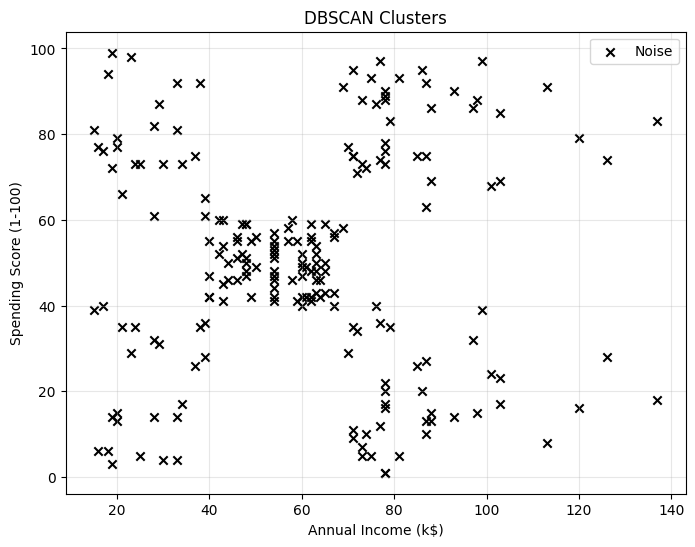

In [ ]:
### extra code

# Visualize DBSCAN clusters (uses 2 numeric columns automatically)
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

# Recompute labels if not present (use same parameters as before)
if 'labels' not in globals():
    dbscan_model = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan_model.fit_predict(data)

# Choose two numeric columns for plotting (prefer the last two numeric columns)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) < 2:
    raise ValueError('Not enough numeric columns to plot clusters (need at least 2).')

x_col, y_col = numeric_cols[-2], numeric_cols[-1]

# Print cluster counts
counts = Counter(labels)
print('Cluster counts (label:count):', dict(counts))

# Plot clusters
unique_labels = np.unique(labels)
colors = plt.cm.get_cmap('tab10', max(1, len(unique_labels)))
plt.figure(figsize=(8,6))
for k in unique_labels:
    mask = (labels == k)
    xy = data.loc[mask, [x_col, y_col]]
    if k == -1:
        # noise
        plt.scatter(xy[x_col], xy[y_col], c='k', marker='x', label='Noise')
    else:
        plt.scatter(xy[x_col], xy[y_col], c=[colors(k % 10)], label=f'Cluster {k}')

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('DBSCAN Clusters')
plt.legend()
plt.grid(alpha=0.3)
plt.show()